# Qwen3-0.6B — autoLRP attribution

Alibaba's Qwen3-0.6B. RMSNorm + RoPE + GQA + SwiGLU. Uses the **AttnLRP recipe** (Achtibat 2024): γ-rule on linear layers, Jacobian backprop through softmax, y/x rule on activations. Reduces the first-token path-count bias plain ε-LRP shows on causal transformers.

In [1]:
import sys
sys.path.insert(0, '..')          # examples/showcase: _common
sys.path.insert(0, '../../..')    # repo root: autoLRP (or `pip install -e .`)
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

import autolrp
from autolrp import LRPConfig
from _common import show_text_attribution, SHOWCASE_PROMPTS

device = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_ID = 'Qwen/Qwen3-0.6B'
MODEL_NAME = 'Qwen3'
FILE_STEM = 'qwen'

/opt/miniconda3/envs/waleed/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tok = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, torch_dtype=torch.float32,
).eval().to(device)

class QwenFromEmb(torch.nn.Module):
    """Embeddings → next-token logits (mean-centered for LRP)."""
    def __init__(self, m):
        super().__init__()
        self.body = m.model
        self.head = m.lm_head
    def forward(self, inputs_embeds):
        h = self.body(
            inputs_embeds=inputs_embeds,
            use_cache=False,              # ← add this
        ).last_hidden_state
        logits = self.head(h)[:, -1, :]
        return logits

wrapper = QwenFromEmb(model).eval().to(device)

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 311/311 [00:02<00:00, 110.28it/s]


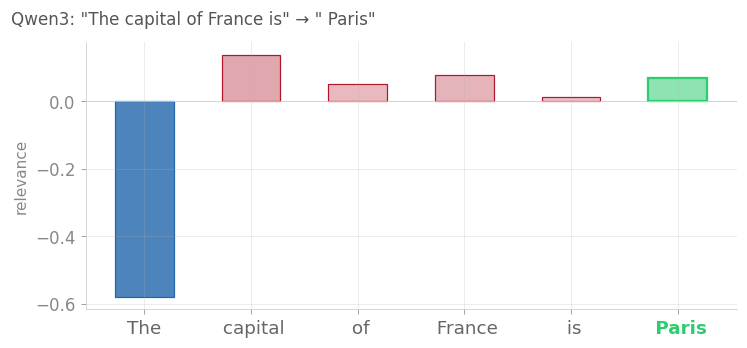

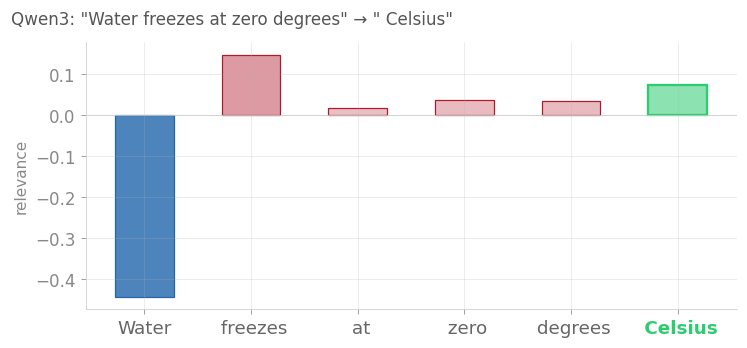

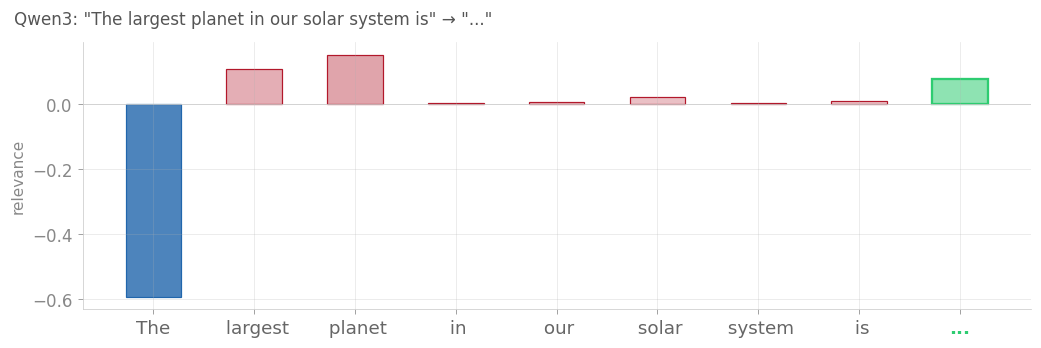

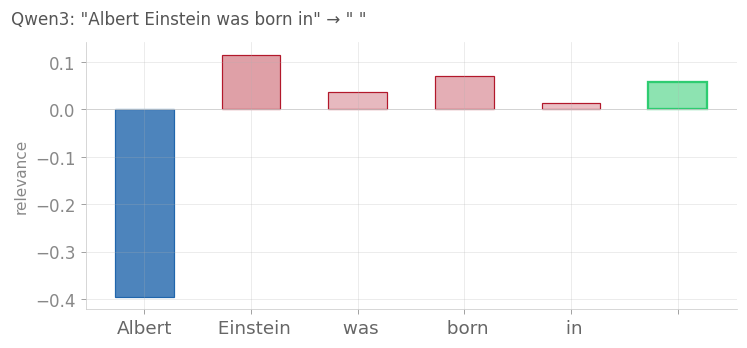

In [3]:
for pi, text in enumerate(SHOWCASE_PROMPTS):
    ids = tok(text, return_tensors='pt').input_ids.to(device)
    emb = model.model.embed_tokens(ids).detach()

    with torch.no_grad():
        pred = wrapper(emb).argmax(-1).item()
    predicted = tok.decode([pred])

    x = autolrp.tensor(emb)
    out = wrapper(x)
    # AttnLRP recipe (Achtibat 2024) — γ-rule on linear, Jacobian softmax,
    # y/x activation. Reduces the path-count bias toward the first token
    # in causal transformers.
    out[0, pred].lrp(config=LRPConfig.attnlrp(gamma=0.25))

    tokens = tok.convert_ids_to_tokens(ids[0])
    rel = x.relevance[0].sum(-1).detach().cpu().numpy()
    show_text_attribution(tokens, rel, predicted_token=predicted,
                         prompt_text=f'{MODEL_NAME}: "{text}" → "{predicted}"')